    This model contains 4 set of diffrenentional eqiation  to determine the  NEURAL DYNAMICS OF THE SYSTEM 
Those are as follows
1.  $$ C_m \frac{dV}{dt} = \underbrace{\bar{g}_{Na} m^3(V)h(V)( E_{Na} - V)}_{\mathrm{Ion_{Na}^+} } + \underbrace{\bar{g}_{K} n (E_{K} - V)}_{\mathrm{Ion_{K}^+}} + \underbrace{\bar{g}_{L}(E_L - V)}_{\mathrm{Ion_{Leak}}}$$
    
    * **$C_m \frac{dV}{dt}$** : The capacitive current (change in voltage)
    *  ___It discribe change in membrane voltage driven by ionic current flowing through the membrane___
------  
$$
\begin{cases}
2.  \frac{dm}{dt} = \alpha_{m}(V)(1-m)-\beta_{m}(V)_{m} \\
3.  \frac{dh}{dt} = \alpha_{h}(V)(1-h)-\beta_{h}(V)_{h} \\
4.  \frac{dn}{dt} = \alpha_{n}(V)(1-n)-\beta_{n}(V)_{n}
\end{cases}
$$

* The other three equation monitor the praportion of open ion channels which them selves depend on voltage  creating an feedback loop
------

### Imports

In [15]:
using DifferentialEquations, Plots,CSV,DataFrames

### Defining the constant

In [2]:

# Voltage-dependent rate functions for the gating variables
# V is in millivolts (mV). These specific forms are tuned for a resting potential around -65mV.

α_m(V) = 0.1 * (V + 40.0) / (1.0 - exp(-(V + 40.0) / 10.0))
β_m(V) = 4.0 * exp(-(V + 65.0) / 18.0)

α_h(V) = 0.07 * exp(-(V + 65.0) / 20.0)
β_h(V) = 1.0 / (1.0 + exp(-(V + 35.0) / 10.0))

α_n(V) = 0.01 * (V + 55.0) / (1.0 - exp(-(V + 55.0) / 10.0))
β_n(V) = 0.125 * exp(-(V + 65.0) / 80.0)


β_n (generic function with 1 method)

In [3]:
function hodgkin_huxley!(du, u, p, t)
    V, m, h, n = u
    I_ext, g_Na, g_K, g_L, E_Na, E_K, E_L, C = p

    # 1. Calculate ionic currents
    I_Na = g_Na * (m^3) * h * (V - E_Na)
    I_K  = g_K * (n^4) * (V - E_K)
    I_L  = g_L * (V - E_L)

    # 2. Membrane potential differential equation
    du[1] = (I_ext - I_Na - I_K - I_L) / C

    # 3. Gating variable differential equations (dx/dt = α(1-x) - βx)
    du[2] = α_m(V) * (1 - m) - β_m(V) * m
    du[3] = α_h(V) * (1 - h) - β_h(V) * h
    du[4] = α_n(V) * (1 - n) - β_n(V) * n
end

hodgkin_huxley! (generic function with 1 method)

In [ ]:
# Standard HH Parameters
p = (
    I_ext = 10,  # External current (μA/cm²) - Try changing this to 2.0 or 20.0!
    g_Na  = 120.0, # Max Sodium conductance (mS/cm²)
    g_K   = 36.0,  # Max Potassium conductance (mS/cm²)
    g_L   = 0.3,   # Leak conductance (mS/cm²)
    E_Na  = 50.0,  # Sodium reversal potential (mV)
    E_K   = -77.0, # Potassium reversal potential (mV)
    E_L   = -54.4, # Leak reversal potential (mV)
    C     = 1.0    # Membrane capacitance (μF/cm²)
)

    # Initial conditions: [V, m, h, n] roughly at resting state
    u0 = [-65.0, 0.05, 0.6, 0.32]
    tspan = (0.0, .0) # Simulate for 50 milliseconds

# Solve the system
prob = ODEProblem(hodgkin_huxley!, u0, tspan, p)
sol = solve(prob, Rodas5P(), reltol=1e-7, abstol=1e-7,saveat=0.01)

retcode: Success
Interpolation: 1st order linear
t: 10001-element Vector{Float64}:
   0.0
   0.01
   0.02
   0.03
   0.04
   0.05
   0.06
   0.07
   0.08
   0.09
   ⋮
  99.92
  99.93
  99.94
  99.95
  99.96
  99.97
  99.98
  99.99
 100.0
u: 10001-element Vector{Vector{Float64}}:
 [-65.0, 0.05, 0.6, 0.32]
 [-64.90343882924655, 0.050133561756837634, 0.5999934588745955, 0.31999710345427573]
 [-64.80744865239966, 0.050285956058566374, 0.59998295391884, 0.3199969174026642]
 [-64.7120152816708, 0.050456349448660356, 0.5999684966634748, 0.3199994299098877]
 [-64.61712497546431, 0.0506439556885105, 0.5999500981427773, 0.32000462930585394]
 [-64.52276439332199, 0.050848032983518615, 0.5999277689146093, 0.32001250417495397]
 [-64.4289205543332, 0.051067880869875404, 0.5999015190626733, 0.3200230433561992]
 [-64.33558080226894, 0.0513028381365682, 0.5998713582135069, 0.32003623593442915]
 [-64.24273277534111, 0.05155228090959027, 0.5998372955569761, 0.3200520712288455]
 [-64.15036436810576, 0.051

In [12]:
size(sol[1, :])

(10001,)

In [13]:
sol[2]

4-element Vector{Float64}:
 -64.90343882924655
   0.050133561756837634
   0.5999934588745955
   0.31999710345427573

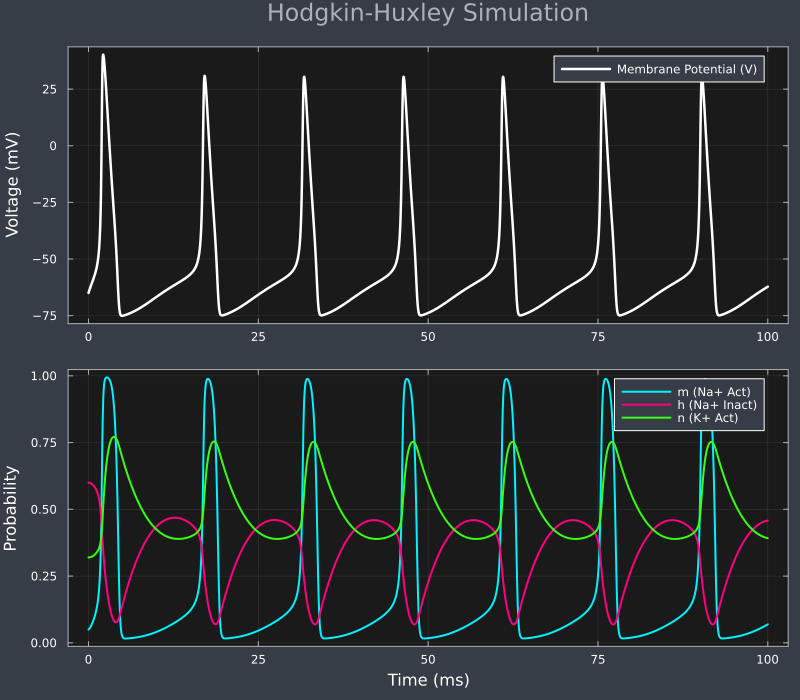

In [14]:


# Choose a dark theme for that "Neon" look
theme(:dark) 

# Define the Neon Color Palette from your image
neon_cyan = "#00f2ff"   # m_inf / tau_m
neon_pink = "#ff007f"   # h_inf / tau_h
neon_green = "#39ff14"  # n_inf / tau_n
background_charcoal = "#1a1a1a"

# Plotting the Voltage (Top Plot)
p1 = plot(sol.t, sol[1,:], 
          label="Membrane Potential (V)", 
          ylabel="Voltage (mV)", 
          color=:white, 
          linewidth=2.5,
          background_color_inside = background_charcoal,
          framestyle = :box)

# Plotting the Gating Variables (Bottom Plot)
p2 = plot(sol.t, sol[2,:], 
          label="m (Na+ Act)", 
          color=neon_cyan, 
          linewidth=2,
          background_color_inside = background_charcoal)

plot!(p2, sol.t, sol[3,:], 
      label="h (Na+ Inact)", 
      color=neon_pink, 
      linewidth=2)

plot!(p2, sol.t, sol[4,:], 
      label="n (K+ Act)", 
      color=neon_green, 
      linewidth=2,
      xlabel="Time (ms)", 
      ylabel="Probability",
      framestyle = :box)

# Combine plots with a clean layout
plot(p1, p2, layout=(2,1), size=(800, 700), plot_title="Hodgkin-Huxley Simulation")

### F_I curve

In [9]:
I_range = collect(0.0:0.5:25)
all_sol = []

for i in I_range
          # Standard HH Parameters
          p = (
              I_ext = i,  # External current (μA/cm²) - Try changing this to 2.0 or 20.0!
              g_Na  = 120.0, # Max Sodium conductance (mS/cm²)
              g_K   = 36.0,  # Max Potassium conductance (mS/cm²)
              g_L   = 0.3,   # Leak conductance (mS/cm²)
              E_Na  = 50.0,  # Sodium reversal potential (mV)
              E_K   = -77.0, # Potassium reversal potential (mV)
              E_L   = -54.4, # Leak reversal potential (mV)
              C     = 1.0    # Membrane capacitance (μF/cm²)
          )

          # Initial conditions: [V, m, h, n] roughly at resting state
          u0 = [-65.0, 0.05, 0.6, 0.32]
          tspan = (0.0, 50.0) # Simulate for 50 milliseconds

          # Solve the system
          prob = ODEProblem(hodgkin_huxley!, u0, tspan, p)
          sol = solve(prob, Tsit5(), reltol=1e-6, abstol=1e-6)
          push!(all_sol,sol)



          
end

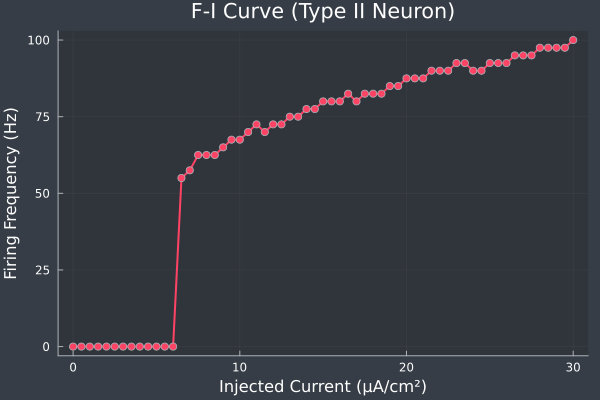

In [10]:
# 1. SETUP THE SWEEP
I_range = 0.0:0.5:30.0    
frequencies = zeros(length(I_range)) # Pre-allocation is faster in Julia

# 2. THE OUTER LOOP
for (idx, I_val) in enumerate(I_range)
    
    # Define your initial conditions (from your working sim)
    u0 = [-65.0, 0.05, 0.6, 0.32] # [V, m, h, n]
    tspan = (0.0, 500.0)
    
    # Update the external current parameter
    # Assuming p = [I_ext, gNa, gK, gL, ENa, EK, EL, C]
    p = [I_val, 120.0, 36.0, 0.3, 50.0, -77.0, -54.4, 1.0] 
    
    prob = ODEProblem(hodgkin_huxley!, u0, tspan, p)
    
    # Solve with a fixed 'saveat' so counting is consistent
    sol = solve(prob, Rosenbrock23(), saveat=0.1)
    
    # 3. SPIKE COUNTING LOGIC
    V = sol[1, :]
    time = sol.t
    spike_count = 0
    
    # We only count spikes after 100ms to ignore the 'startup' transient
    for i in 2:length(V)
        if time[i] > 100.0
            if V[i] >= 0.0 && V[i-1] < 0.0
                spike_count += 1
            end
        end
    end
    
    # 4. CALCULATE FREQUENCY (Hz)
    # Time window is 400ms = 0.4 seconds
    frequencies[idx] = spike_count / 0.4
end

# 5. FINAL PLOT
plot(I_range, frequencies, 
     title="F-I Curve (Type II Neuron)", 
     xlabel="Injected Current (μA/cm²)", 
     ylabel="Firing Frequency (Hz)",
     marker=:circle, 
     linewidth=2, 
     legend=false)

In [11]:
frequencies

61-element Vector{Float64}:
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   ⋮
  92.5
  95.0
  95.0
  95.0
  97.5
  97.5
  97.5
  97.5
 100.0

### ⚙️ Final Two Differential Equations
*(Standard 2-variable Hodgkin–Huxley reduction)*

Assume $m \approx m_\infty(V)$ and $h \approx h_\infty(V)$.
Then the reduced system becomes:

$$
\boxed{
C_m \frac{dV}{dt}
= - g_{Na} \, m_\infty(V)^3 \, h_\infty(V) \, (V - E_{Na})
- g_K \, n^4 (V - E_K)
- g_L (V - E_L)
+ I_{\text{ext}}
}
$$

$$
\boxed{
\frac{dn}{dt} = \frac{n_\infty(V) - n}{\tau_n(V)}
}
$$

---

### 🧩 Parameter Definitions

* $C_m$: membrane capacitance
* $g_{Na}, g_K, g_L$: maximum conductances
* $E_{Na}, E_K, E_L$: reversal potentials

And the voltage-dependent steady-state functions:

$$
m_\infty(V) = \frac{\alpha_m(V)}{\alpha_m(V) + \beta_m(V)}, \quad
h_\infty(V) = \frac{\alpha_h(V)}{\alpha_h(V) + \beta_h(V)}, \quad
n_\infty(V) = \frac{\alpha_n(V)}{\alpha_n(V) + \beta_n(V)}
$$

Time constant for $n$:

$$
\tau_n(V) = \frac{1}{\alpha_n(V) + \beta_n(V)}
$$

In [31]:
sol.t

10001-element Vector{Float64}:
   0.0
   0.01
   0.02
   0.03
   0.04
   0.05
   0.06
   0.07
   0.08
   0.09
   ⋮
  99.92
  99.93
  99.94
  99.95
  99.96
  99.97
  99.98
  99.99
 100.0

### Saving the Synthetic_data to file

In [33]:
output_path = raw"C:\\Users\\ADMIN\\Downloads\\Neural_Spiking_Dynamics\\notebooks\\1_data_generation\\100ms_synthethic_0_noise_data.csv"
df = DataFrame(
    timestamp    =  sol.t,
    V=sol[1, :],
    m=sol[2, :],
    n=sol[3, :],
    h=sol[4, :]
    
)

Row,timestamp,V,m,n,h
,Float64,Float64,Float64,Float64,Float64
1,0.0,-65.0,0.05,0.6,0.32
2,0.01,-64.9034,0.0501336,0.599993,0.319997
3,0.02,-64.8074,0.050286,0.599983,0.319997
4,0.03,-64.712,0.0504563,0.599968,0.319999
5,0.04,-64.6171,0.050644,0.59995,0.320005
6,0.05,-64.5228,0.050848,0.599928,0.320013
7,0.06,-64.4289,0.0510679,0.599902,0.320023
8,0.07,-64.3356,0.0513028,0.599871,0.320036
9,0.08,-64.2427,0.0515523,0.599837,0.320052


In [34]:
CSV.write(output_path,df)


"C:\\\\Users\\\\ADMIN\\\\Downloads\\\\Neural_Spiking_Dynamics\\\\notebooks\\\\1_data_generation\\\\100ms_synthethic_0_noise_data.csv"

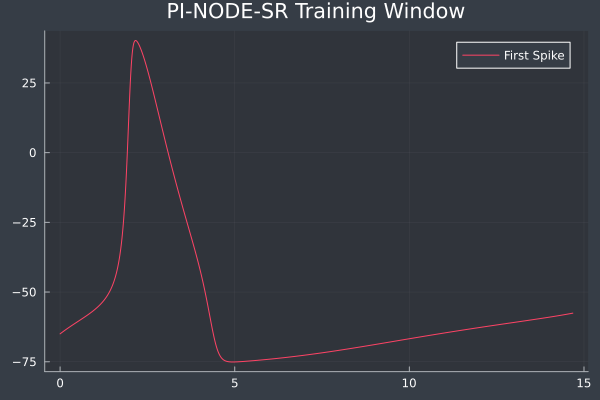

In [51]:
# Plotting the first 1469 points (roughly 0 to 14.68 ms)
plot(df.timestamp[1:1469], df.V[1:1469], label="First Spike", title="PI-NODE-SR Training Window")


## Adding the noise to the data ( DF)
### deterministic Ornstein-Uhlenbeck (OU) noise
#### $$ dx = -\theta x dt + \sigma dW $$


In [43]:

function ou_noise(t,data,θ=5.0, σ=0.5)
    noise = zeros(length(t))
    for i in 2:(length(t))
        dt = t[i]-t[i-1]
        # OU formula: current_noise + drift + Random shock
        noise[i] = noise[i-1] - θ * noise[i-1] * dt + σ * sqrt(dt) * randn()
    end
    return noise


end

ou_noise (generic function with 3 methods)

In [52]:
v_noisy = ou_noise(df.timestamp[1:1469], df.V[1:1469])
m_noisy = ou_noise(df.timestamp[1:1469], df.m[1:1469])
n_noisy = ou_noise(df.timestamp[1:1469], df.n[1:1469])
h_noisy = ou_noise(df.timestamp[1:1469], df.h[1:1469])

1469-element Vector{Float64}:
  0.0
 -0.07964879243116528
 -0.09108244810201291
 -0.12278244596601615
 -0.050523400446016054
 -0.04812696281904817
 -0.0627521688910897
 -0.11721616971285816
 -0.19894422081385757
 -0.1682284830116944
  ⋮
  0.1415707495188227
  0.07003728964234514
 -0.03824948444506436
 -0.014717110934932404
 -0.05031447027721701
 -0.11080702556138686
 -0.13242044475063913
 -0.12242028358723762
 -0.09127012138007329

In [55]:
# Now saving the noisy data
output_path2 = raw"C:\Users\ADMIN\Downloads\Neural_Spiking_Dynamics\notebooks\1_data_generation\single_spike_noisy_data.csv"
noisy_df = DataFrame(
    timestamp    =  df.timestamp[1:1469],
    V=v_noisy,
    m=m_noisy,
    n=n_noisy,
    h=h_noisy
    
)
CSV.write(output_path,noisy_df)


"C:\\\\Users\\\\ADMIN\\\\Downloads\\\\Neural_Spiking_Dynamics\\\\notebooks\\\\1_data_generation\\\\100ms_synthethic_0_noise_data.csv"

# PI-NODE-SR Refactoring (Optimized for GPU/Float32)

In [ ]:
using Lux, SciMLSensitivity, Optimization, OptimizationOptimisers, Statistics, Random, ComponentArrays, StaticArrays, Zygote
using CUDA

In [ ]:
p = Float32[
    10.0f0,  # I_ext
    120.0f0, # g_Na
    36.0f0,  # g_K
    0.3f0,   # g_L
    50.0f0,  # E_Na
    -77.0f0, # E_K
    -54.4f0, # E_L
    1.0f0    # C
]
u0 = Float32[-65.0f0, 0.05f0, 0.6f0, 0.32f0]
tspan = (0.0f0, 50.0f0)


In [ ]:
α_m(V) = 0.1f0 * (V + 40.0f0) / (1.0f0 - exp(-(V + 40.0f0) / 10.0f0))
β_m(V) = 4.0f0 * exp(-(V + 65.0f0) / 18.0f0)
α_h(V) = 0.07f0 * exp(-(V + 65.0f0) / 20.0f0)
β_h(V) = 1.0f0 / (1.0f0 + exp(-(V + 35.0f0) / 10.0f0))
α_n(V) = 0.01f0 * (V + 55.0f0) / (1.0f0 - exp(-(V + 55.0f0) / 10.0f0))
β_n(V) = 0.125f0 * exp(-(V + 65.0f0) / 80.0f0)


In [ ]:
function hodgkin_huxley!(du, u, p, t)
    V, m, h, n = u
    I_ext, g_Na, g_K, g_L, E_Na, E_K, E_L, C = p

    # 1. Calculate ionic currents
    I_Na = g_Na .* (m.^3) .* h .* (V .- E_Na)
    I_K  = g_K .* (n.^4) .* (V .- E_K)
    I_L  = g_L .* (V .- E_L)

    # 2. Membrane potential differential equation
    du[1] = (I_ext .- I_Na .- I_K .- I_L) ./ C

    # 3. Gating variable differential equations (dx/dt = α(1-x) - βx)
    du[2] = α_m.(V) .* (1f0 .- m) .- β_m.(V) .* m
    du[3] = α_h.(V) .* (1f0 .- h) .- β_h.(V) .* h
    du[4] = α_n.(V) .* (1f0 .- n) .- β_n.(V) .* n
end


In [ ]:
rng = Random.default_rng()
nn = Lux.Chain(
    Lux.Dense(5 => 64, Lux.tanh),
    Lux.LayerNorm(64),
    Lux.Dense(64 => 64, Lux.tanh),
    Lux.LayerNorm(64),
    Lux.Dense(64 => 4)
)
ps, st = Lux.setup(rng, nn)
p_flat, reconstruct = Optimisers.destructure(ps)
p_initial = Float32.(p_flat)


In [ ]:
function neural_dynamics(u, p, t)
    ps_structured = reconstruct(p)
    raw_input = vcat(u, t) 
    input_2d = reshape(raw_input, :, 1)
    dudt_2d, _ = nn(input_2d, ps_structured, st) 
    return vec(dudt_2d)
end
node_prob = ODEProblem(neural_dynamics, u0, tspan, p_initial)


In [ ]:
# Generate ground truth training data using the optimized HH model
true_prob = ODEProblem(hodgkin_huxley!, u0, tspan, p)
true_sol = solve(true_prob, Heun(), dt=0.1f0, saveat=0.5f0)
t_train = Float32.(true_sol.t)
z_train = Float32.(Array(true_sol))


In [ ]:
function calculate_scale_factors(z_train, t_train)
    dt = diff(t_train)
    dz = diff(z_train, dims=2)
    derivatives = dz ./ dt'
    s_factors = std(derivatives, dims=2)
    # Fallback to avoid division by zero
    return max.(s_factors, 1e-5f0)
end
scale_factors = calculate_scale_factors(z_train, t_train)


In [ ]:
function predict(θ)
    new_prob = remake(node_prob, p=θ)
    return solve(new_prob, Heun(), 
                 saveat=t_train, 
                 reltol=1e-3, abstol=1e-3, dt=0.1f0,
                 sensealg=InterpolatingAdjoint())
end


In [ ]:
function physics_loss(θ, state_data, time_data, scale_factors)
    ps_current = reconstruct(θ)
    nn_inputs = vcat(state_data, time_data')
    pred_derivs, _ = nn(nn_inputs, ps_current, st)

    true_derivs = zeros(Float32, size(state_data))
    for i in 1:size(state_data, 2)
        # In-place derivatives calculation
        du_temp = MVector{4, Float32}(0f0,0f0,0f0,0f0)
        hodgkin_huxley!(du_temp, state_data[:, i], p, time_data[i])
        true_derivs[:, i] .= du_temp
    end

    residuals = (pred_derivs .- true_derivs) ./ scale_factors
    return mean(residuals.^2)
end


In [ ]:
function total_loss(θ, _)
    sol = predict(θ)
    if sol.retcode != ReturnCode.Success
        return Inf32
    end
    
    # Data loss
    loss_data = mean(abs2, Array(sol) .- z_train)
    
    # Physics residual loss
    loss_phys = physics_loss(θ, z_train, t_train, scale_factors)
    
    λ = 1.5f0
    return loss_data + λ * loss_phys
end


In [ ]:
loss_history = Float32[]
callback_fn = function (θ, loss_val)
    push!(loss_history, loss_val)
    if length(loss_history) % 10 == 0
        println("Iteration: $(length(loss_history)) | Loss: $(loss_val)")
    end
    return false
end

optf = OptimizationFunction(total_loss, Optimization.AutoZygote())
optprob = OptimizationProblem(optf, p_initial)

println("Starting Training...")
# Train for 10 epochs to verify loss convergence quickly
result = solve(optprob, Adam(0.01), maxiters = 10, callback = callback_fn)
println("Training Complete!")
